# PaySim Dataset - Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the PaySim dataset.

The main objectives are:

- Understand the structure of the dataset
- Analyze transaction types and amounts
- Check missing and duplicate records
- Analyze account balances
- Understand fraudulent transactions
- Study class imbalance
- Identify useful patterns for fraud detection

Since the PaySim dataset is large, it is processed using chunks to reduce memory usage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
file_path = "../data/paysim.csv"

print("File exists:", os.path.exists(file_path))

File exists: True


In [3]:
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)

print(f"Dataset size: {file_size_mb:.2f} MB")

Dataset size: 470.67 MB


In [4]:
sample = pd.read_csv(file_path, nrows=10000)

print("Sample shape:", sample.shape)

Sample shape: (10000, 11)


In [5]:
sample.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
sample.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
9995,7,PAYMENT,466.73,C517929856,881.0,414.27,M2128130537,0.0,0.0,0,0
9996,7,PAYMENT,8239.66,C1483641522,11515.0,3275.34,M1108211033,0.0,0.0,0,0
9997,7,PAYMENT,6063.34,C728110179,31409.0,25345.66,M277524255,0.0,0.0,0,0
9998,7,TRANSFER,317806.64,C1021138110,10901.0,0.00,C1935506329,103168.0,0.0,0,0
9999,7,PAYMENT,5096.16,C299358529,60472.0,55375.84,M176755220,0.0,0.0,0,0


In [7]:
print("Columns in PaySim dataset:\n")

for i, column in enumerate(sample.columns, start=1):
    print(f"{i}. {column}")

Columns in PaySim dataset:

1. step
2. type
3. amount
4. nameOrig
5. oldbalanceOrg
6. newbalanceOrig
7. nameDest
8. oldbalanceDest
9. newbalanceDest
10. isFraud
11. isFlaggedFraud


In [8]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            10000 non-null  int64  
 1   type            10000 non-null  object 
 2   amount          10000 non-null  float64
 3   nameOrig        10000 non-null  object 
 4   oldbalanceOrg   10000 non-null  float64
 5   newbalanceOrig  10000 non-null  float64
 6   nameDest        10000 non-null  object 
 7   oldbalanceDest  10000 non-null  float64
 8   newbalanceDest  10000 non-null  float64
 9   isFraud         10000 non-null  int64  
 10  isFlaggedFraud  10000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 859.5+ KB


In [9]:
sample.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,10000.000000,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,1.000000e+04,10000.000000,10000.0
mean,4.178900,1.035467e+05,8.939330e+05,9.152741e+05,9.342758e+05,1.096606e+06,0.006800,0.0
std,2.479821,2.663072e+05,2.135683e+06,2.181428e+06,2.676340e+06,3.014496e+06,0.082185,0.0
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,1.000000,4.397530e+03,1.276875e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,5.000000,1.285874e+04,2.137556e+04,1.034994e+04,0.000000e+00,0.000000e+00,0.000000,0.0
75%,7.000000,1.143825e+05,1.782719e+05,1.760934e+05,2.831067e+05,2.520552e+05,0.000000,0.0
max,7.000000,1.000000e+07,1.293042e+07,1.301050e+07,1.951612e+07,1.916920e+07,1.000000,0.0


In [10]:
missing_values = sample.isnull().sum()

missing_values

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [11]:
missing_summary = pd.DataFrame({
    "Missing Values": sample.isnull().sum(),
    "Missing Percentage": (sample.isnull().sum() / len(sample)) * 100
})

missing_summary

,Missing Values,Missing Percentage
step,0,0.0
type,0,0.0
amount,0,0.0
nameOrig,0,0.0
oldbalanceOrg,0,0.0
newbalanceOrig,0,0.0
nameDest,0,0.0
oldbalanceDest,0,0.0
newbalanceDest,0,0.0
isFraud,0,0.0


In [12]:
duplicate_count = sample.duplicated().sum()

print("Duplicate rows in sample:", duplicate_count)

Duplicate rows in sample: 0


In [13]:
sample["type"].value_counts()

type
PAYMENT     5465
CASH_IN     1949
CASH_OUT    1321
TRANSFER     921
DEBIT        344
Name: count, dtype: int64

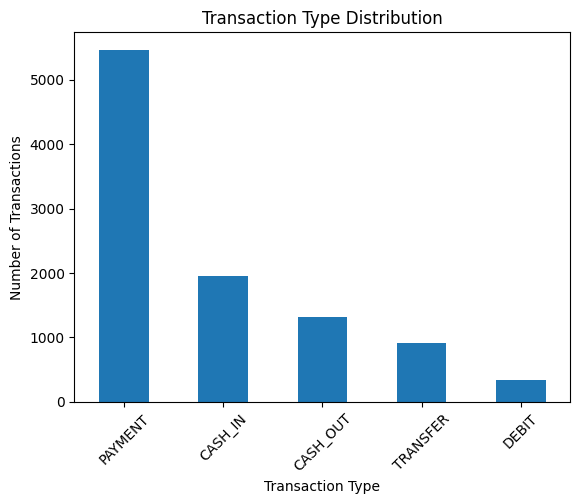

In [14]:
sample["type"].value_counts().plot(kind="bar")

plt.title("Transaction Type Distribution")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [15]:
transaction_type_percentage = (
    sample["type"].value_counts(normalize=True) * 100
)

transaction_type_percentage

type
PAYMENT     54.65
CASH_IN     19.49
CASH_OUT    13.21
TRANSFER     9.21
DEBIT        3.44
Name: proportion, dtype: float64

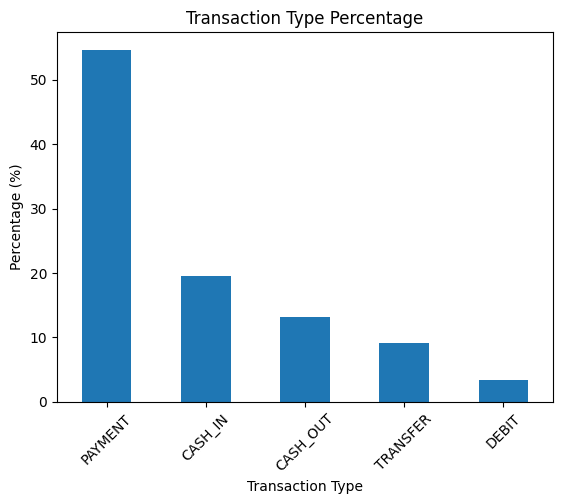

In [16]:
transaction_type_percentage.plot(kind="bar")

plt.title("Transaction Type Percentage")
plt.xlabel("Transaction Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.show()

In [18]:
sample["amount"].describe()

sample.nlargest(10, "amount")[
    ["type", "amount", "isFraud"]
]

,type,amount,isFraud
4440,TRANSFER,10000000.00,1
4441,CASH_OUT,10000000.00,1
1153,TRANSFER,3776389.09,0
9635,TRANSFER,2940764.72,0
4442,TRANSFER,2930418.44,1
4443,CASH_OUT,2930418.44,1
4155,TRANSFER,2837270.65,0
1823,TRANSFER,2604219.11,0
7699,TRANSFER,2576294.80,0
375,TRANSFER,2545478.01,0


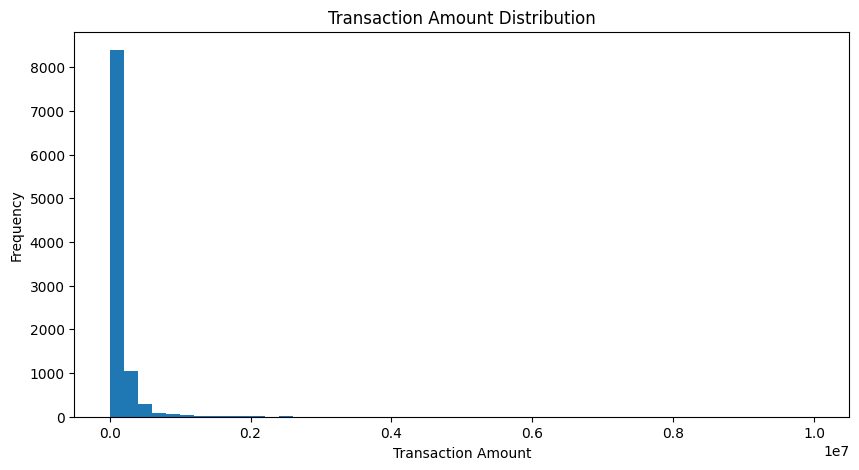

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(sample["amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

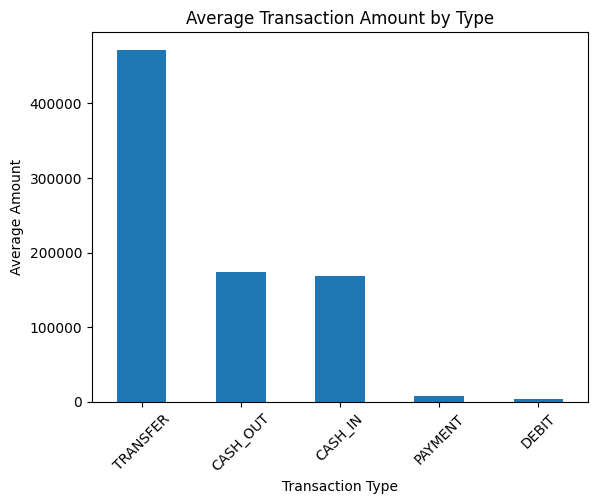

In [20]:
sample.groupby("type")["amount"].mean().sort_values(ascending=False)

sample.groupby("type")["amount"].mean().sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Average Transaction Amount by Type")
plt.xlabel("Transaction Type")
plt.ylabel("Average Amount")
plt.xticks(rotation=45)

plt.show()

In [23]:
sample["isFraud"].value_counts()

fraud_percentage = (
    sample["isFraud"].value_counts(normalize=True) * 100
)

fraud_percentage

isFraud
0    99.32
1     0.68
Name: proportion, dtype: float64

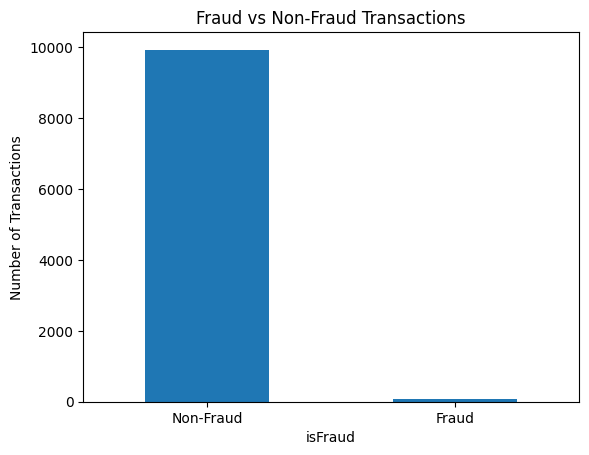

In [24]:

sample["isFraud"].value_counts().plot(
    kind="bar"
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Number of Transactions")
plt.xticks(
    [0, 1],
    ["Non-Fraud", "Fraud"],
    rotation=0
)

plt.show()

In [25]:
fraud_table = pd.DataFrame({
    "Count": sample["isFraud"].value_counts(),
    "Percentage": sample["isFraud"].value_counts(normalize=True) * 100
})

fraud_table

,Count,Percentage
isFraud,,
0,9932,99.32
1,68,0.68


In [26]:
fraud_by_type = pd.crosstab(
    sample["type"],
    sample["isFraud"]
)

fraud_by_type

isFraud,0,1
type,,
CASH_IN,1949,0
CASH_OUT,1286,35
DEBIT,344,0
PAYMENT,5465,0
TRANSFER,888,33


In [27]:
fraud_by_type.columns = [
    "Non-Fraud",
    "Fraud"
]

fraud_by_type

,Non-Fraud,Fraud
type,,
CASH_IN,1949,0
CASH_OUT,1286,35
DEBIT,344,0
PAYMENT,5465,0
TRANSFER,888,33


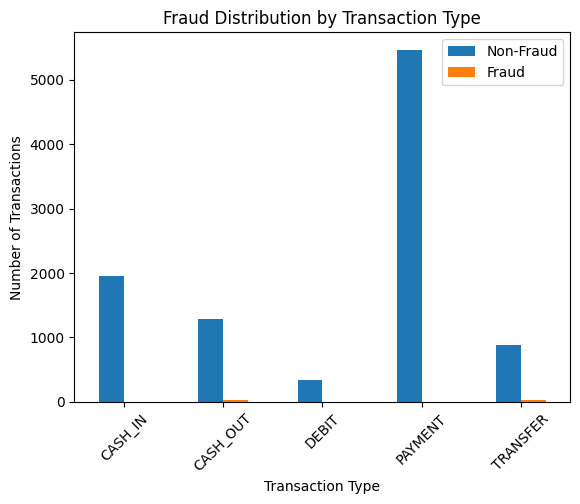

In [28]:
fraud_by_type.plot(kind="bar")

plt.title("Fraud Distribution by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()

In [29]:
fraud_rate_by_type = (
    sample.groupby("type")["isFraud"]
    .mean() * 100
)

fraud_rate_by_type.sort_values(
    ascending=False
)

type
TRANSFER    3.583062
CASH_OUT    2.649508
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64

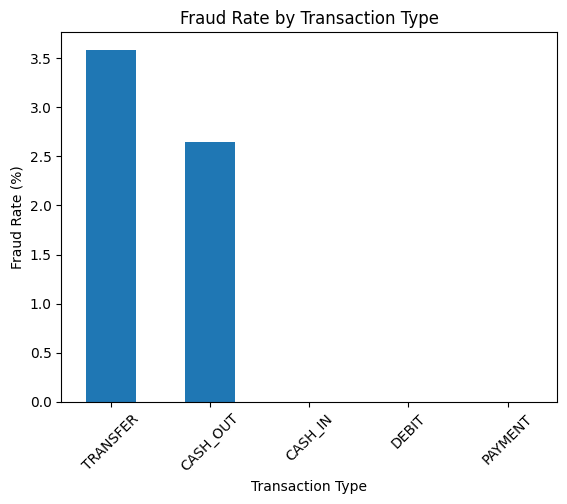

In [30]:
fraud_rate_by_type.sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [33]:
sample.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,9932.0,100603.239233,2.222295e+05,2.39,4372.755,12740.655,114059.9425,3776389.09
1,68.0,533463.638676,1.753539e+06,181.00,14949.840,28644.760,181561.7975,10000000.00


In [34]:
sample.groupby("isFraud")["amount"].mean()

isFraud
0    100603.239233
1    533463.638676
Name: amount, dtype: float64

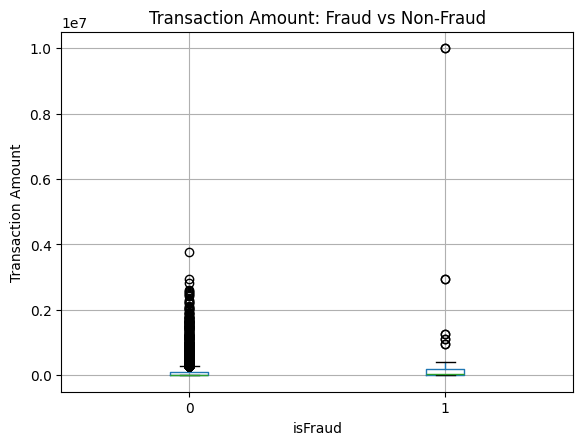

In [35]:
sample.boxplot(
    column="amount",
    by="isFraud"
)

plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.suptitle("")
plt.xlabel("isFraud")
plt.ylabel("Transaction Amount")

plt.show()

In [38]:
fraud_transactions = sample[
    sample["isFraud"] == 1
]

print(fraud_transactions.head())

print(
    "Fraudulent transactions in sample:",
    len(fraud_transactions)
)

     step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
2       1  TRANSFER    181.0  C1305486145          181.0             0.0   
3       1  CASH_OUT    181.0   C840083671          181.0             0.0   
251     1  TRANSFER   2806.0  C1420196421         2806.0             0.0   
252     1  CASH_OUT   2806.0  C2101527076         2806.0             0.0   
680     1  TRANSFER  20128.0   C137533655        20128.0             0.0   

        nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
2     C553264065             0.0             0.0        1               0  
3      C38997010         21182.0             0.0        1               0  
251   C972765878             0.0             0.0        1               0  
252  C1007251739         26202.0             0.0        1               0  
680  C1848415041             0.0             0.0        1               0  
Fraudulent transactions in sample: 68


In [39]:
fraud_transactions["type"].value_counts()


type
CASH_OUT    35
TRANSFER    33
Name: count, dtype: int64

In [40]:
fraud_transactions["type"].value_counts(
    normalize=True
) * 100

type
CASH_OUT    51.470588
TRANSFER    48.529412
Name: proportion, dtype: float64

In [41]:
sample["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    10000
Name: count, dtype: int64

In [42]:
pd.crosstab(
    sample["isFraud"],
    sample["isFlaggedFraud"]
)

isFlaggedFraud,0
isFraud,
0,9932
1,68


In [45]:
sample[
    [
        "oldbalanceOrg",
        "newbalanceOrig"
    ]
].describe()

,oldbalanceOrg,newbalanceOrig
count,1.000000e+04,1.000000e+04
mean,8.939330e+05,9.152741e+05
std,2.135683e+06,2.181428e+06
min,0.000000e+00,0.000000e+00
25%,1.276875e+02,0.000000e+00
50%,2.137556e+04,1.034994e+04
75%,1.782719e+05,1.760934e+05
max,1.293042e+07,1.301050e+07


In [46]:
sample[
    [
        "oldbalanceDest",
        "newbalanceDest"
    ]
].describe()

,oldbalanceDest,newbalanceDest
count,1.000000e+04,1.000000e+04
mean,9.342758e+05,1.096606e+06
std,2.676340e+06,3.014496e+06
min,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00
50%,0.000000e+00,0.000000e+00
75%,2.831067e+05,2.520552e+05
max,1.951612e+07,1.916920e+07


In [49]:
sample["origin_balance_change"] = (
    sample["oldbalanceOrg"]
    - sample["newbalanceOrig"]
)

sample["origin_balance_change"].describe()

count    1.000000e+04
mean    -2.134106e+04
std      1.805159e+05
min     -1.030100e+06
25%      0.000000e+00
50%      5.488050e+02
75%      5.831355e+03
max      1.000000e+07
Name: origin_balance_change, dtype: float64

In [51]:
sample["destination_balance_change"] = (
    sample["newbalanceDest"]
    - sample["oldbalanceDest"]
)

sample["destination_balance_change"].describe()

count    1.000000e+04
mean     1.623306e+05
std      1.005081e+06
min     -1.306083e+07
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.826902e+07
Name: destination_balance_change, dtype: float64

In [52]:
sample["origin_difference"] = (
    sample["amount"]
    - sample["origin_balance_change"]
)

sample[
    [
        "amount",
        "origin_balance_change",
        "origin_difference",
        "isFraud"
    ]
].head()

,amount,origin_balance_change,origin_difference,isFraud
0,9839.64,9839.64,-1.455192e-11,0
1,1864.28,1864.28,1.136868e-12,0
2,181.00,181.00,0.000000e+00,1
3,181.00,181.00,0.000000e+00,1
4,11668.14,11668.14,0.000000e+00,0


In [53]:
sample.groupby("isFraud")[
    "oldbalanceOrg"
].mean()

isFraud
0    896160.769435
1    568552.955588
Name: oldbalanceOrg, dtype: float64

In [54]:
sample.groupby("isFraud")[
    "newbalanceOrig"
].mean()

isFraud
0    921245.524515
1     43094.388824
Name: newbalanceOrig, dtype: float64

In [55]:
sample.groupby("isFraud")[
    "oldbalanceDest"
].mean()

isFraud
0    938926.900268
1    254942.847794
Name: oldbalanceDest, dtype: float64

In [56]:
sample.groupby("isFraud")[
    "newbalanceDest"
].mean()

isFraud
0    1.099322e+06
1    7.000055e+05
Name: newbalanceDest, dtype: float64

In [57]:
print("Minimum step:", sample["step"].min())
print("Maximum step:", sample["step"].max())
print("Unique steps:", sample["step"].nunique())

Minimum step: 1
Maximum step: 7
Unique steps: 7


In [58]:
transactions_per_step = sample.groupby(
    "step"
).size()

transactions_per_step.head()

step
1    2708
2    1014
3     552
4     565
5     665
dtype: int64

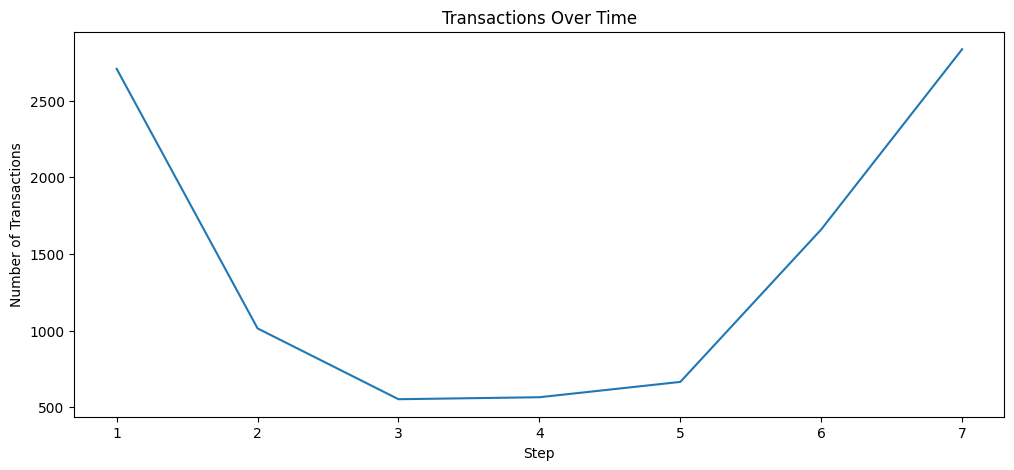

In [59]:
transactions_per_step.plot(
    figsize=(12, 5)
)

plt.title("Transactions Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Transactions")

plt.show()

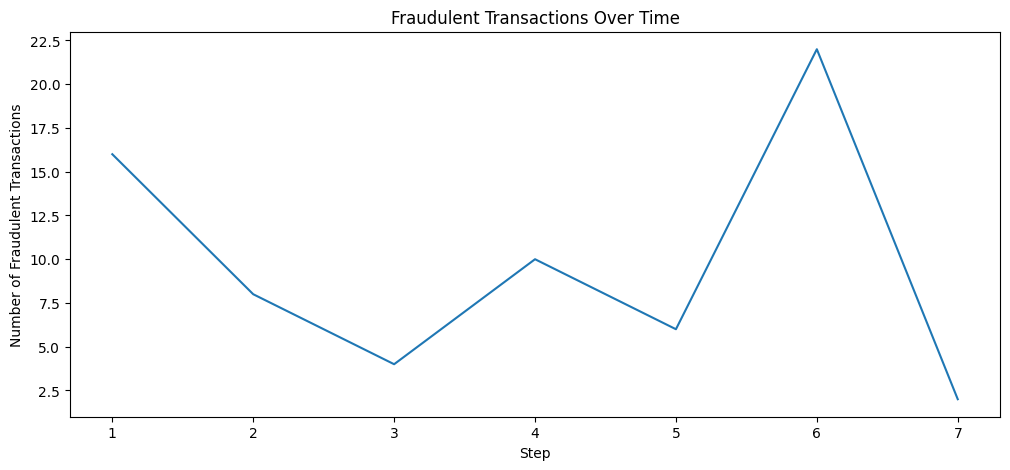

In [60]:
fraud_per_step = sample.groupby(
    "step"
)["isFraud"].sum()

fraud_per_step.plot(
    figsize=(12, 5)
)

plt.title("Fraudulent Transactions Over Time")
plt.xlabel("Step")
plt.ylabel("Number of Fraudulent Transactions")

plt.show()

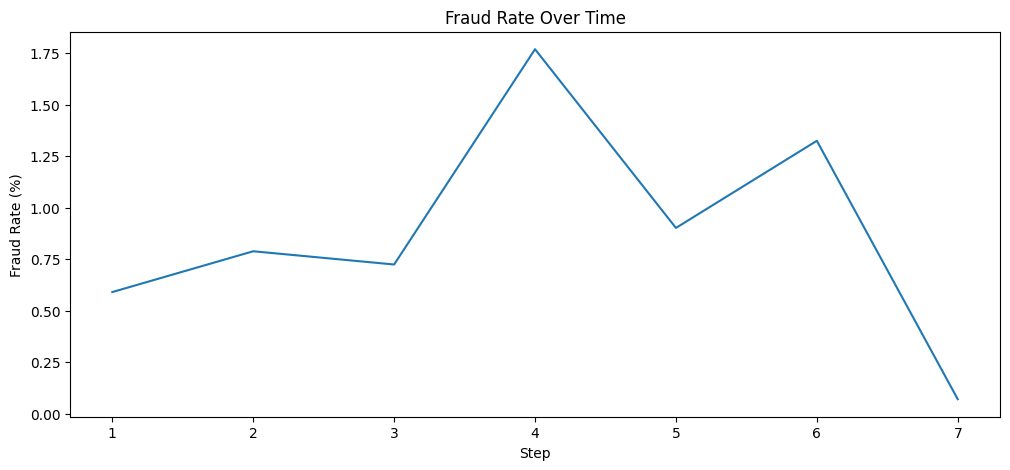

In [61]:
fraud_rate_per_step = sample.groupby(
    "step"
)["isFraud"].mean() * 100

fraud_rate_per_step.plot(
    figsize=(12, 5)
)

plt.title("Fraud Rate Over Time")
plt.xlabel("Step")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [62]:
print(
    "Unique origin accounts:",
    sample["nameOrig"].nunique()
)

print(
    "Unique destination accounts:",
    sample["nameDest"].nunique()
)

Unique origin accounts: 10000
Unique destination accounts: 6397


In [63]:
sample["nameOrig"].value_counts().head(10)

nameOrig
C1231006815    1
C891268602     1
C328246293     1
C979049207     1
C1228068224    1
C1979961282    1
C1613065499    1
C38489930      1
C1569330262    1
C2115589111    1
Name: count, dtype: int64

In [64]:
sample["nameDest"].value_counts().head(10)

nameDest
C985934102     62
C1590550415    52
C1286084959    50
C1899073220    44
C977993101     43
C451111351     43
C1782113663    43
C2083562754    41
C1789550256    40
C1360767589    40
Name: count, dtype: int64

In [65]:
fraud_origin_accounts = (
    fraud_transactions["nameOrig"]
    .value_counts()
    .head(10)
)

fraud_origin_accounts

nameOrig
C1305486145    1
C213063852     1
C682812632     1
C457596841     1
C1004271827    1
C864622150     1
C685428529     1
C2025652936    1
C1775746074    1
C840083671     1
Name: count, dtype: int64

In [66]:
fraud_destination_accounts = (
    fraud_transactions["nameDest"]
    .value_counts()
    .head(10)
)

fraud_destination_accounts

nameDest
C410033330     2
C1662235713    1
C904300960     1
C256417920     1
C1956477953    1
C451934410     1
C41792607      1
C1626759869    1
C553264065     1
C1249547869    1
Name: count, dtype: int64

In [67]:
balance_columns = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

for column in balance_columns:
    print(
        column,
        "negative values:",
        (sample[column] < 0).sum()
    )

amount negative values: 0
oldbalanceOrg negative values: 0
newbalanceOrig negative values: 0
oldbalanceDest negative values: 0
newbalanceDest negative values: 0


In [68]:
for column in [
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]:
    
    print(
        column,
        "zero values:",
        (sample[column] == 0).sum()
    )

oldbalanceOrg zero values: 2424
newbalanceOrig zero values: 4064
oldbalanceDest zero values: 5680
newbalanceDest zero values: 5826


In [69]:
chunksize = 500000

total_rows = 0
fraud_count = 0
non_fraud_count = 0

for chunk in pd.read_csv(
    file_path,
    chunksize=chunksize
):
    
    total_rows += len(chunk)
    
    fraud_count += (
        chunk["isFraud"] == 1
    ).sum()
    
    non_fraud_count += (
        chunk["isFraud"] == 0
    ).sum()

print("Total rows:", total_rows)
print("Fraudulent transactions:", fraud_count)
print("Non-fraudulent transactions:", non_fraud_count)

Total rows: 6362620
Fraudulent transactions: 8213
Non-fraudulent transactions: 6354407


In [70]:
fraud_percentage = (
    fraud_count / total_rows
) * 100

non_fraud_percentage = (
    non_fraud_count / total_rows
) * 100

print(
    f"Fraud transactions: {fraud_percentage:.4f}%"
)

print(
    f"Non-fraud transactions: {non_fraud_percentage:.4f}%"
)

Fraud transactions: 0.1291%
Non-fraud transactions: 99.8709%


In [71]:
type_counts = {}

for chunk in pd.read_csv(
    file_path,
    chunksize=chunksize
):
    
    counts = chunk["type"].value_counts()
    
    for transaction_type, count in counts.items():
        
        type_counts[transaction_type] = (
            type_counts.get(transaction_type, 0)
            + count
        )

type_counts = pd.Series(type_counts)

type_counts.sort_values(
    ascending=False
)

CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
dtype: int64

In [72]:
fraud_type_counts = {}

for chunk in pd.read_csv(
    file_path,
    chunksize=chunksize
):
    
    fraud_chunk = chunk[
        chunk["isFraud"] == 1
    ]
    
    counts = fraud_chunk["type"].value_counts()
    
    for transaction_type, count in counts.items():
        
        fraud_type_counts[transaction_type] = (
            fraud_type_counts.get(transaction_type, 0)
            + count
        )

fraud_type_counts = pd.Series(
    fraud_type_counts
)

fraud_type_counts.sort_values(
    ascending=False
)

CASH_OUT    4116
TRANSFER    4097
dtype: int64

In [73]:
type_total = {}
type_fraud = {}

for chunk in pd.read_csv(
    file_path,
    chunksize=chunksize
):
    
    total_counts = chunk["type"].value_counts()
    
    fraud_counts = (
        chunk.groupby("type")["isFraud"].sum()
    )
    
    for transaction_type, count in total_counts.items():
        
        type_total[transaction_type] = (
            type_total.get(transaction_type, 0)
            + count
        )
    
    for transaction_type, count in fraud_counts.items():
        
        type_fraud[transaction_type] = (
            type_fraud.get(transaction_type, 0)
            + count
        )

In [74]:
fraud_rate = {}

for transaction_type in type_total:
    
    fraud_rate[transaction_type] = (
        type_fraud.get(transaction_type, 0)
        / type_total[transaction_type]
    ) * 100

fraud_rate = pd.Series(
    fraud_rate
).sort_values(
    ascending=False
)

fraud_rate

TRANSFER    0.768799
CASH_OUT    0.183955
PAYMENT     0.000000
CASH_IN     0.000000
DEBIT       0.000000
dtype: float64

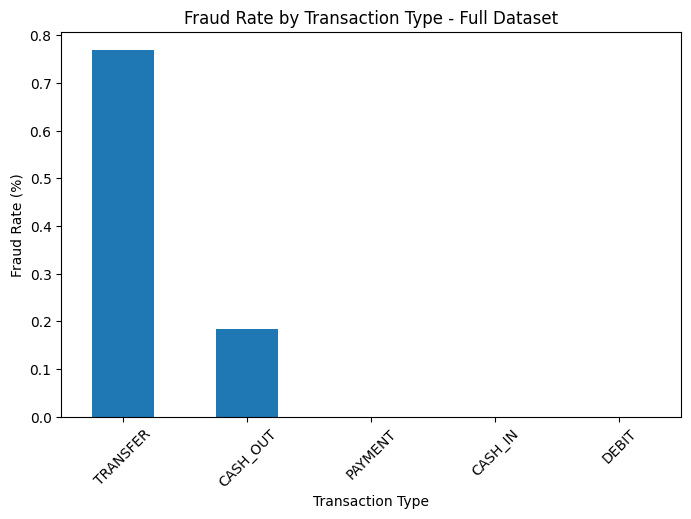

In [75]:
fraud_rate.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Fraud Rate by Transaction Type - Full Dataset")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

In [76]:
eda_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Fraudulent Transactions",
        "Non-Fraudulent Transactions",
        "Fraud Percentage",
        "Non-Fraud Percentage",
        "Number of Transaction Types"
    ],
    
    "Value": [
        total_rows,
        fraud_count,
        non_fraud_count,
        f"{fraud_percentage:.4f}%",
        f"{non_fraud_percentage:.4f}%",
        len(type_counts)
    ]
})

eda_summary

,Metric,Value
0,Total Transactions,6362620
1,Fraudulent Transactions,8213
2,Non-Fraudulent Transactions,6354407
3,Fraud Percentage,0.1291%
4,Non-Fraud Percentage,99.8709%
5,Number of Transaction Types,5


## EDA Conclusions

Based on the exploratory analysis:

1. PaySim contains a highly imbalanced fraud classification problem.
2. Fraudulent transactions represent a very small portion of all transactions.
3. Transaction types have different fraud rates.
4. Transaction amount and account balance information can provide useful fraud-related signals.
5. The `step` column can be used to study transaction behavior over time.
6. `nameOrig` and `nameDest` can be useful for account-level behavioral analysis.
7. `isFlaggedFraud` provides an existing rule-based fraud indicator.
8. Because of the large dataset size, chunk-based processing is required for memory-efficient analysis.

These observations will be used in the next notebook for data preprocessing and feature engineering.